In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
class TrajectoryEnv:
    def __init__(self, max_dx=0.2, max_dy=0.5):
        self.max_steps = 150
        self.max_dx = max_dx
        self.max_dy = max_dy
        self.reset()

    def _get_state(self):
        onde_y = np.sin(self.x)
        onde_pente = np.cos(self.x)
        erreur_relative = self.y - onde_y
        return np.array([onde_y, onde_pente, erreur_relative, self.prev_dy], dtype=np.float32)

    def reset(self):
        self.x = 0.0
        self.y = 0.0
        self.prev_dy = 0.0
        self.current_step = 0

        self.history_x = [self.x]
        self.history_y = [self.y]

        return self._get_state()

    def step(self, action):
        self.current_step += 1
        
        dx = np.clip(action[0], 0.0, 1.0)*self.max_dx
        dy = np.clip(action[1], -1.0, 1.0)*self.max_dy
        
        self.x += dx
        self.y += dy

        self.history_x.append(self.x)
        self.history_y.append(self.y)
        
        cible_y = np.sin(self.x)
        erreur = abs(self.y - cible_y)

        k = 8.0
        c_err = 2.0
        lam_lissage = 0.15
        reward = dx * (1.0 + np.exp(-k * erreur ** 2))
        reward -= c_err * erreur ** 2
        reward -= lam_lissage * abs(dy - self.prev_dy)

        self.prev_dy = dy

        done = self.current_step >= self.max_steps
        
        if erreur > 1.5:
            reward -= 5.0
            done = True
            
        return self._get_state(), float(reward), done
    
    def render(self, titre=""):
        x_parfait = np.linspace(0, max(1.0, self.x), 200)
        y_parfait = np.sin(x_parfait)
        plt.figure(figsize=(10, 5))
        plt.plot(x_parfait, y_parfait, "g--", label="Idéal  y = sin(x)")
        plt.plot(self.history_x, self.history_y, "b-o", markersize=3,
                 label="Trajectoire de l'IA")
        plt.title(titre or f"x_final = {self.x:.1f}")
        plt.legend()
        plt.grid(True)
        plt.show()




Score final de l'agent aléatoire : -19.32


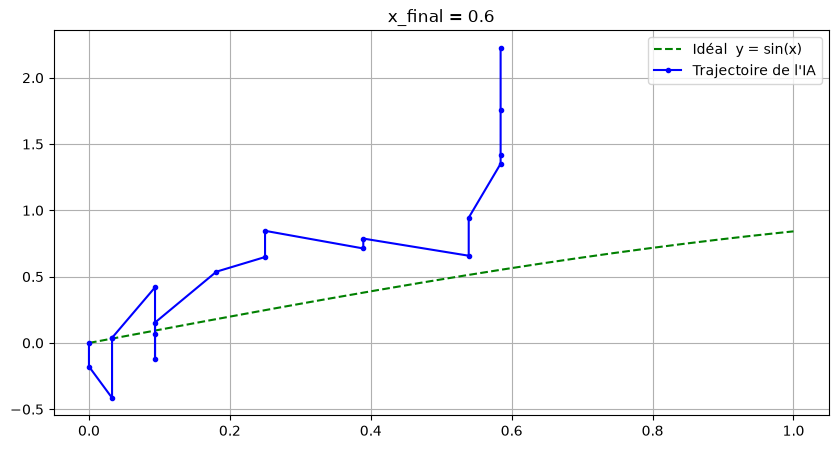

In [2]:
env = TrajectoryEnv()
state = env.reset()
done = False
score_total = 0

while not done:
    rand_act = np.random.uniform(low=-1.0, high=1.0, size=2)
    state, reward, done = env.step(rand_act)
    score_total += reward

print(f"Score final de l'agent aléatoire : {score_total:.2f}")
env.render()

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal

class PPOAgent(nn.Module):
    def __init__(self, state_dim=4, action_dim=2):
        super().__init__()

        self.actor_mean = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.Tanh(),
            nn.Linear(64,64),
            nn.Tanh(),
            nn.Linear(64, action_dim)
        )

        self.actor_log_std = nn.Parameter(torch.zeros(1, action_dim))

        self.critic = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
        )

    def act(self, state):
        with torch.no_grad():
            s = torch.FloatTensor(state).unsqueeze(0)
            mean = self.actor_mean(s)
            std = torch.exp(self.actor_log_std)
            dist = Normal(mean, std)
            action = dist.sample()
            logprob = dist.log_prob(action).sum(axis=-1)
            value = self.critic(s)
        return action.flatten().numpy(), logprob.item(), value.item()
    
    def evaluate(self, states, actions):
        mean = self.actor_mean(states)
        std = torch.exp(self.actor_log_std)
        dist = Normal(mean, std)
        logprobs = dist.log_prob(actions).sum(axis=-1)
        entropy = dist.entropy().sum(axis=-1)
        values = self.critic(states).squeeze(-1)
        return logprobs, values, entropy

In [4]:
class PPOMemory:
    def __init__(self):
        self.clear()
 
    def clear(self):
        self.states, self.actions, self.logprobs = [], [], []
        self.values, self.rewards, self.dones = [], [], []
 


In [5]:
def compute_gae(rewards, values, dones, gamma=0.99, lam=0.95, last_value=0.0):
    """Generalized Advantage Estimation. Retourne (advantages, returns)."""
    vals = values + [last_value]
    advantages, gae = [], 0.0
    for t in reversed(range(len(rewards))):
        mask = 1.0 - float(dones[t])
        delta = rewards[t] + gamma * vals[t + 1] * mask - vals[t]
        gae = delta + gamma * lam * mask * gae
        advantages.insert(0, gae)
    returns = [a + v for a, v in zip(advantages, values)]
    return advantages, returns


def ppo_update(agent, optimizer, memory, eps_clip=0.2, k_epochs=10,
               c_value=0.5, c_entropy=0.01):
    states = torch.FloatTensor(np.array(memory.states))
    actions = torch.FloatTensor(np.array(memory.actions))
    old_logprobs = torch.FloatTensor(memory.logprobs)
 
    advantages, returns = compute_gae(memory.rewards, memory.values, memory.dones)
    advantages = torch.FloatTensor(advantages)
    returns = torch.FloatTensor(returns)
 
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
 
    for _ in range(k_epochs):
        new_logprobs, values, entropy = agent.evaluate(states, actions)
        ratios = torch.exp(new_logprobs - old_logprobs)
 
        surr1 = ratios * advantages
        surr2 = torch.clamp(ratios, 1 - eps_clip, 1 + eps_clip) * advantages
        actor_loss = -torch.min(surr1, surr2).mean()
        critic_loss = nn.MSELoss()(values, returns)
        entropy_bonus = entropy.mean()
 
        loss = actor_loss + c_value * critic_loss - c_entropy * entropy_bonus
 
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(agent.parameters(), 0.5) 
        optimizer.step()
 


Début de l'entraînement...
Épisode 100/2000 | score moyen (100 derniers) : -25.833
Épisode 200/2000 | score moyen (100 derniers) : -32.579
Épisode 300/2000 | score moyen (100 derniers) : -37.174
Épisode 400/2000 | score moyen (100 derniers) : -60.063
Épisode 500/2000 | score moyen (100 derniers) : -26.216
Épisode 600/2000 | score moyen (100 derniers) : -1.085
Épisode 700/2000 | score moyen (100 derniers) : 10.394
Épisode 800/2000 | score moyen (100 derniers) : 14.197
Épisode 900/2000 | score moyen (100 derniers) : 15.461
Épisode 1000/2000 | score moyen (100 derniers) : 15.964
Épisode 1100/2000 | score moyen (100 derniers) : 16.804
Épisode 1200/2000 | score moyen (100 derniers) : 17.442
Épisode 1300/2000 | score moyen (100 derniers) : 18.323
Épisode 1400/2000 | score moyen (100 derniers) : 18.659
Épisode 1500/2000 | score moyen (100 derniers) : 19.186
Épisode 1600/2000 | score moyen (100 derniers) : 20.108
Épisode 1700/2000 | score moyen (100 derniers) : 20.733
Épisode 1800/2000 | score

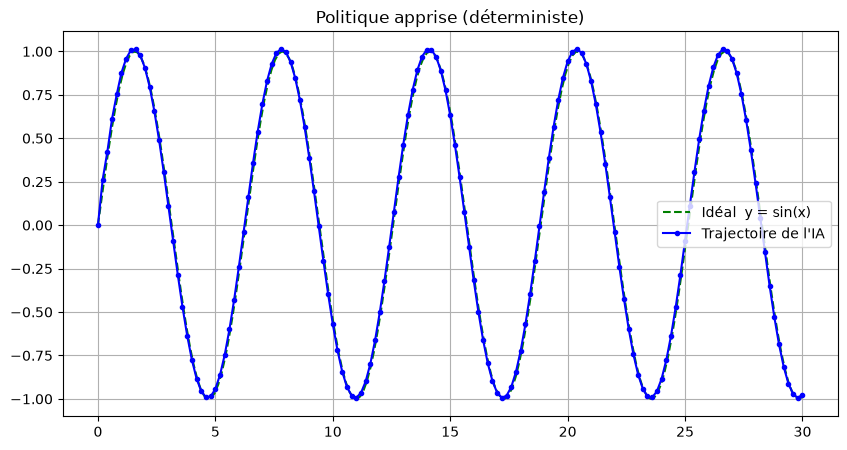

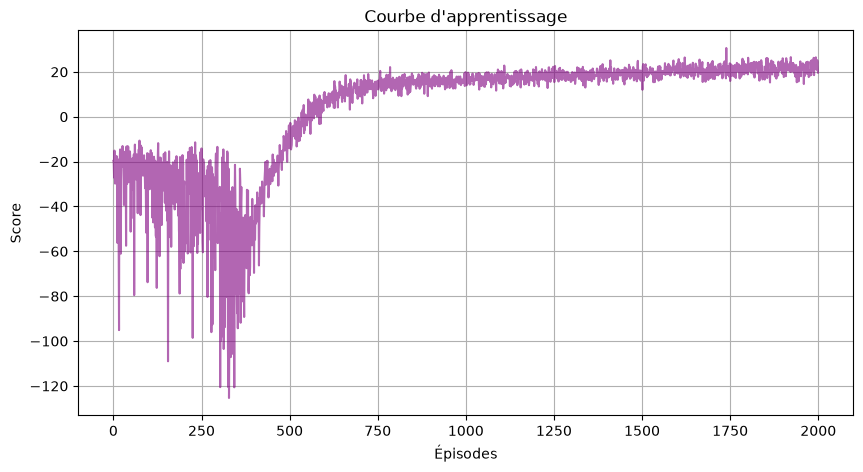

In [6]:
from IPython.display import clear_output
import matplotlib.pyplot as plt

env = TrajectoryEnv()
agent = PPOAgent(state_dim=4, action_dim=2)
optimizer = optim.Adam(agent.parameters(), lr=3e-4)
memory = PPOMemory()

max_episodes = 2000
update_timestep = 2000
timestep_counter = 0

historique_scores = []

print("Début de l'entraînement...")

for episode in range(1, max_episodes + 1):
    state = env.reset()
    score_episode = 0.0
    done = False
    while not done:
        timestep_counter += 1

        action, logprob, value = agent.act(state)

        next_state, reward, done = env.step(action)

        memory.states.append(state)
        memory.actions.append(action)
        memory.logprobs.append(logprob)
        memory.values.append(value)
        memory.rewards.append(reward)
        memory.dones.append(done)

        state = next_state
        score_episode += reward

        if timestep_counter % update_timestep == 0:
            ppo_update(agent, optimizer, memory)
            memory.clear()

    historique_scores.append(score_episode)

    if episode % 100 == 0:
        moy = np.mean(historique_scores[-100:])
        print(f"Épisode {episode}/{max_episodes} | score moyen (100 derniers) : {moy:.3f}")


state = env.reset()
done = False
while not done:
    with torch.no_grad():
        mean = agent.actor_mean(torch.FloatTensor(state).unsqueeze(0))
    state, _, done = env.step(mean.flatten().numpy())
env.render("Politique apprise (déterministe)")
 
plt.figure(figsize=(10, 5))
plt.plot(historique_scores, color="purple", alpha=0.6)
plt.title("Courbe d'apprentissage")
plt.xlabel("Épisodes")
plt.ylabel("Score")
plt.grid(True)
plt.show()




Alerte : Coup de vent violent vers le haut !
Alerte : Coup de vent violent vers le bas !


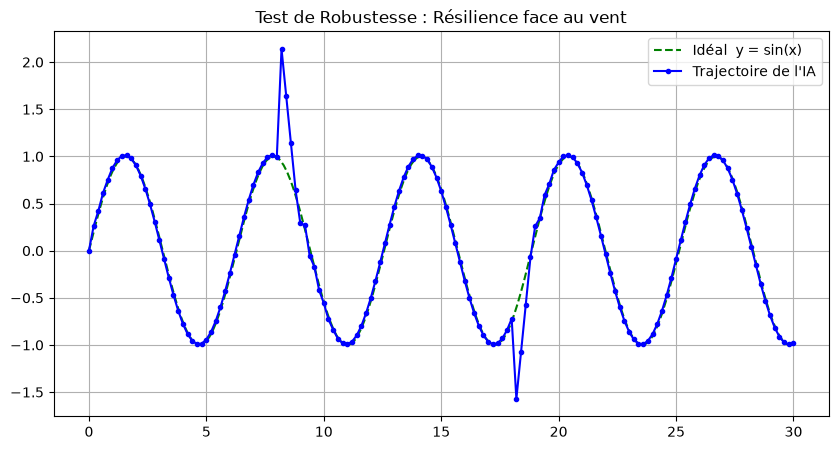

In [7]:
import torch

state = env.reset()
done = False

while not done:
    with torch.no_grad():
        action = agent.actor_mean(torch.FloatTensor(state).unsqueeze(0)).flatten().numpy()
        if env.current_step == 40:
            print("Alerte : Coup de vent violent vers le haut !")
            env.y += 1.2 
        
        elif env.current_step == 90:
            print("Alerte : Coup de vent violent vers le bas !")
            env.y -= 1.0 
        
        state, _, done = env.step(action)

env.render("Test de Robustesse : Résilience face au vent")
